# Libraries

In [26]:
!pip install -r https://raw.githubusercontent.com/Abdelrahmanemam01/Sentiment-Analysis/main/BERT/requirements.txt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Note: you may need to restart the kernel to use updated packages.


In [1]:
# Standard Library Imports
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# PyTorch
import torch

# Hugging Face Datasets & Transformers
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
    pipeline
)

from sklearn.utils.class_weight import compute_class_weight

# Hugging Face Hub & Kaggle
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

# Evaluation Metrics
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

2025-12-29 20:33:44.645426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767040424.815506      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767040424.870321      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767040425.287696      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767040425.287739      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767040425.287743      55 computation_placer.cc:177] computation placer alr

# HyperParameters

In [2]:
SEED = 42
model_ckpt = "bert-base-uncased"
dataset_name = "emotion"
repo = 'abdelrahmane01/SentimentAnalysis-bert-base-uncased-finetuned-emotion'
num_labels = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model Configurations

batch_size = 16
epochs = 6
lr = 1e-5
w_decay = 0.01
PATIENCE = 2

# Functions

In [3]:
# Reproducibility
def set_all_seeds(seed: int) -> None:
    """Set seeds for full reproducibility."""
    
    # Python & NumPy
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    # PyTorch (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # cuDNN (deterministic behavior)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Label Utilities
def add_label_names(
    df: pd.DataFrame,
    label_column: str,
    label_feature,
    new_column: str = "label_name",
) -> pd.DataFrame:
    """Add human-readable label names to a DataFrame."""
    
    df[new_column] = df[label_column].apply(label_feature.int2str)
    return df


# Tokenization
def make_tokenize_fn(max_length: int):
    """Create a tokenizer function with fixed max length."""
    
    def tokenize(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=max_length,
        )

    return tokenize


# Metrics
def compute_metrics(pred):
    """Compute evaluation metrics for Trainer."""
    
    labels = pred.label_ids
    preds = pred.predictions.argmax(axis=-1)

    return {
        "f1_macro": f1_score(labels, preds, average="macro"),
        "accuracy": accuracy_score(labels, preds),
    }

# Classes

In [4]:
class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_fct = torch.nn.CrossEntropyLoss(weight=class_weights)

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None
    ):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss = self.loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

# Seed for reproducibility

In [5]:
set_all_seeds(SEED)

# Preprocessing & Visualization

**Load Dataset**

In [6]:
emotions = load_dataset(dataset_name)

README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [7]:
emotions

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [8]:
train_ds = emotions['train']
val_ds = emotions['validation']
test_ds = emotions['test']

train_ds[:5]

{'text': ['i didnt feel humiliated',
  'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
  'im grabbing a minute to post i feel greedy wrong',
  'i am ever feeling nostalgic about the fireplace i will know that it is still on the property',
  'i am feeling grouchy'],
 'label': [0, 0, 3, 2, 3]}

**Change to dataframe**

In [9]:
train_df = train_ds.to_pandas()

val_df = val_ds.to_pandas()

test_df = test_ds.to_pandas()

train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


**Change label to class_name**

In [10]:
label_feature = emotions["train"].features["label"]

train_df = add_label_names(
    train_df,
    label_column="label",
    label_feature=label_feature
)

val_df = add_label_names(
    val_df,
    label_column="label",
    label_feature=label_feature
)

test_df = add_label_names(
    test_df,
    label_column="label",
    label_feature=label_feature
)

train_df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


**Check frequency of classes**

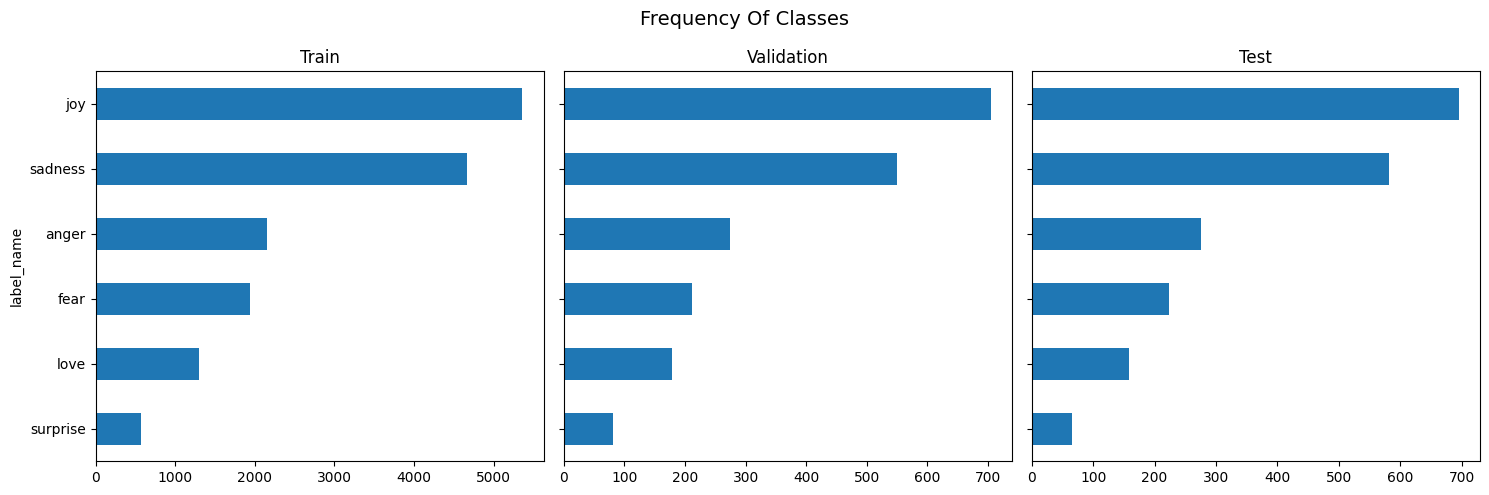

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

datasets = [
    (train_df, "Train"),
    (val_df, "Validation"),
    (test_df, "Test")
]

for ax, (df, name) in zip(axes, datasets):
    counts = df['label_name'].value_counts(ascending=True)
    counts.plot.barh(ax=ax)
    ax.set_title(name)

fig.suptitle("Frequency Of Classes", fontsize=14)
plt.tight_layout()
plt.show()

**Tweet's  Token Length**

In [12]:
# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

# Tokenization
encodings = tokenizer(
    train_df['text'].tolist(),
    padding=False,
    truncation=False
)

# Calculate Tokens Per Tweet
train_df['num_tokens'] = [len(ids) for ids in encodings['input_ids']]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [13]:
print("Maximum context size of Bert is ", tokenizer.model_max_length)

train_df['num_tokens'].describe()

Maximum context size of Bert is  512


count    16000.000000
mean        22.259500
std         11.575801
min          4.000000
25%         13.000000
50%         20.000000
75%         29.000000
max         87.000000
Name: num_tokens, dtype: float64

**Limit Tweets to Max_length**

In [14]:
p97 = int(np.percentile(train_df['num_tokens'], 97))
print("97% of my tweets is <= ", p97)
max_length = 64
tokenize = make_tokenize_fn(max_length)

97% of my tweets is <=  49


**Tokenization**

In [15]:
emotions_encoded = emotions.map(tokenize, batched=True, batch_size=1000)
emotions_encoded = emotions_encoded.with_format("torch")

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

**Load Model**

In [16]:
set_all_seeds(SEED)
model = AutoModelForSequenceClassification.from_pretrained(model_ckpt, num_labels=num_labels).to(device)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Fine Tuning

**Weighted Class**

In [17]:
labels = np.array(emotions_encoded["train"]["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

# soften extreme weights
class_weights = np.sqrt(class_weights)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

**Training Arguments**

In [18]:
# Step calculation
eval_save_steps = len(emotions_encoded["train"]) // batch_size # evaluate & save once per epoch


# Training Arguments
training_args = TrainingArguments(
    # Output
    output_dir="/kaggle/working/tmp",
    num_train_epochs=epochs,

    # Optimization
    learning_rate=lr,
    weight_decay=w_decay,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,

    # Evaluation & Saving
    eval_strategy="steps",
    eval_steps=eval_save_steps,
    save_strategy="steps",
    save_steps=eval_save_steps,

    # Best Model Handling
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1_macro",
    greater_is_better=True,

    # Logging
    logging_strategy="steps",
    logging_steps=eval_save_steps,
    logging_first_step=True,
    log_level="error",

    # Misc
    disable_tqdm=False,
    report_to="none",

    # Hugging Face Hub
    push_to_hub=False
)


# Trainer
trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=emotions_encoded["train"],
    eval_dataset=emotions_encoded["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=PATIENCE
        )
    ]
)

/tmp/ipykernel_55/3674314347.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)


**Training**

In [19]:
# Train
trainer.train()


# Final Evaluation
# Best checkpoint is already loaded because:
# load_best_model_at_end=True

# Validation
val_metrics = trainer.evaluate()
trainer.log_metrics("eval", val_metrics)
trainer.save_metrics("eval", val_metrics)

# Test
test_metrics = trainer.evaluate(emotions_encoded["test"])
trainer.log_metrics("test", test_metrics)
trainer.save_metrics("test", test_metrics)


# Push to Hub
try:
    trainer.push_to_hub()
except Exception:
    print("Not logged in to Hugging Face — skipping push_to_hub")

Step,Training Loss,Validation Loss,F1 Macro,Accuracy
1000,0.733400,0.250831,0.894106,0.917000
2000,0.201600,0.188127,0.909551,0.933000
3000,0.145000,0.198091,0.911917,0.935500
4000,0.117800,0.222868,0.915838,0.939000
5000,0.090300,0.246889,0.916074,0.938500
6000,0.080800,0.248942,0.909957,0.935500


***** eval metrics *****
  epoch                   =        6.0
  eval_accuracy           =     0.9385
  eval_f1_macro           =     0.9161
  eval_loss               =     0.2469
  eval_runtime            = 0:00:04.04
  eval_samples_per_second =    493.971
  eval_steps_per_second   =     30.873
***** test metrics *****
  epoch                   =        6.0
  eval_accuracy           =     0.9215
  eval_f1_macro           =     0.8801
  eval_loss               =     0.2913
  eval_runtime            = 0:00:04.16
  eval_samples_per_second =    479.794
  eval_steps_per_second   =     29.987
Not logged in to Hugging Face — skipping push_to_hub


**Validation Set**

**Classification Report**

In [20]:
# Get predictions on validation set
preds_output = trainer.predict(emotions_encoded["validation"])

y_val_true = preds_output.label_ids
y_val_pred = np.argmax(preds_output.predictions, axis=1)

# Class names
label_names = emotions["validation"].features["label"].names

val_report = classification_report(
    y_val_true,
    y_val_pred,
    target_names=label_names,
    digits=3
)

print(val_report)

              precision    recall  f1-score   support

     sadness      0.960     0.960     0.960       550
         joy      0.960     0.959     0.959       704
        love      0.898     0.893     0.896       178
       anger      0.955     0.920     0.937       275
        fear      0.882     0.882     0.882       212
    surprise      0.806     0.926     0.862        81

    accuracy                          0.939      2000
   macro avg      0.910     0.923     0.916      2000
weighted avg      0.939     0.939     0.939      2000



**Confusion Matrix**

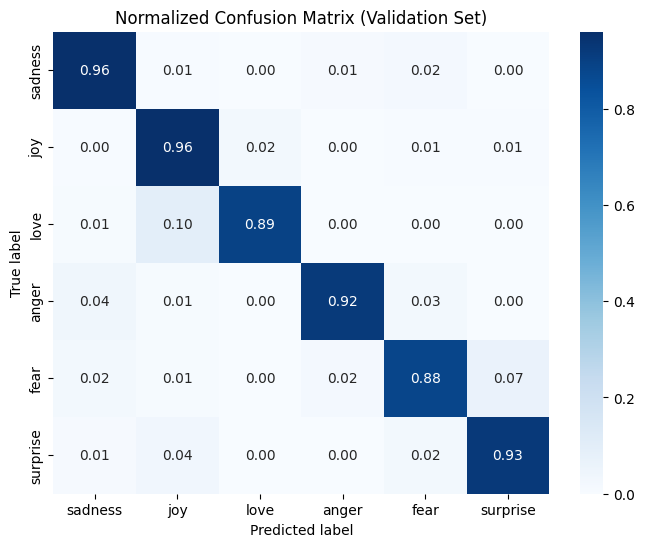

In [21]:
# Normalized confusion matrix
cm_norm = confusion_matrix(
    y_val_true,
    y_val_pred,
    normalize="true"
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (Validation Set)")

# Save BEFORE show
plt.savefig(
    "confusion_matrix_validation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Test Set**

**Classification Report**

In [22]:
# Get predictions on test set
preds_output = trainer.predict(emotions_encoded["test"])

y_test_true = preds_output.label_ids
y_test_pred = np.argmax(preds_output.predictions, axis=1)

# Class names
label_names = emotions["test"].features["label"].names

test_report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=label_names,
    digits=3
)

print(test_report)

              precision    recall  f1-score   support

     sadness      0.955     0.960     0.958       581
         joy      0.956     0.937     0.946       695
        love      0.795     0.881     0.836       159
       anger      0.929     0.905     0.917       275
        fear      0.913     0.844     0.877       224
    surprise      0.667     0.848     0.747        66

    accuracy                          0.921      2000
   macro avg      0.869     0.896     0.880      2000
weighted avg      0.925     0.921     0.923      2000



**Confusion Matrix**

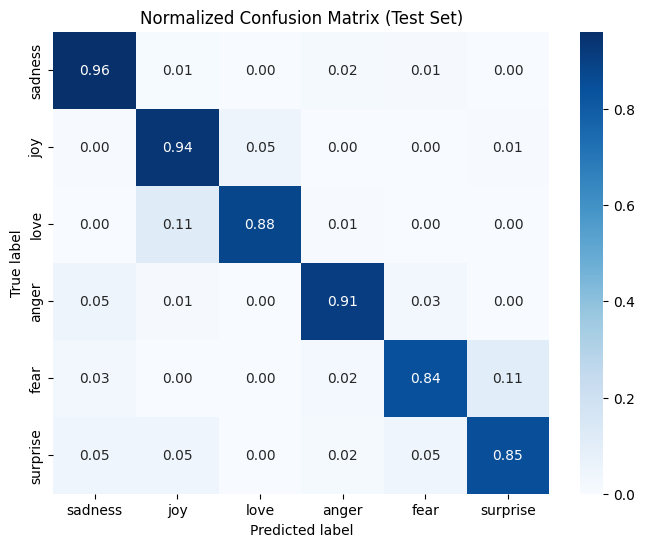

In [23]:
# Normalized confusion matrix (each row sums to 1)
cm_norm = confusion_matrix(
    y_test_true,
    y_test_pred,
    normalize="true"
)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (Test Set)")

# Save BEFORE show
plt.savefig(
    "confusion_matrix_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Evaluation

**BERT**

In [24]:
tokenizer = AutoTokenizer.from_pretrained(repo)
model = AutoModelForSequenceClassification.from_pretrained(repo)
model.to(device)
model.eval()

# Batched input
batch_size = 32
tweet = "I saw my crush today, and she was beautiful as usual."
texts = [tweet] * batch_size

# Tokenization
inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
).to(device)

# Warm-up
with torch.no_grad():
    for _ in range(5):
        _ = model(**inputs)

# Timed inference
with torch.no_grad():
    torch.cuda.synchronize()
    start = time.time()

    outputs = model(**inputs)

    torch.cuda.synchronize()
    end = time.time()

batch_time_ms = (end - start) * 1000
per_sample_ms = batch_time_ms / batch_size

print(f"Batch size: {batch_size}")
print(f"Total batch time: {batch_time_ms:.2f} ms")
print(f"Per-sample time: {per_sample_ms:.2f} ms")

# Probabilities
probs = torch.softmax(outputs.logits, dim=-1)

# Labels
labels = list(model.config.id2label.values())

# Result for ONE sample
result_df = (
    pd.DataFrame({
        "label": labels,
        "probability (%)": probs[0].cpu().numpy() * 100
    })
    .sort_values("probability (%)", ascending=False)
    .reset_index(drop=True) 
)

print(result_df.to_string(index=False))

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/927 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Batch size: 32
Total batch time: 17.99 ms
Per-sample time: 0.56 ms
   label  probability (%)
     joy        99.725204
    love         0.112529
 sadness         0.067743
surprise         0.040485
   anger         0.038323
    fear         0.015717


**DistilBERT**

In [25]:
model_id = "abdelrahmane01/SentimentAnalysis-distilbert-base-uncased-finetuned-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForSequenceClassification.from_pretrained(model_id)
model.to(device)
model.eval()

# Batched input
batch_size = 32
tweet = "I saw my crush today, and she was beautiful as usual."
texts = [tweet] * batch_size

# Tokenization
inputs = tokenizer(
    texts,
    padding=True,
    truncation=True,
    return_tensors="pt"
).to(device)

# Warm-up
with torch.no_grad():
    for _ in range(5):
        _ = model(**inputs)

# Timed inference
with torch.no_grad():
    torch.cuda.synchronize()
    start = time.time()

    outputs = model(**inputs)

    torch.cuda.synchronize()
    end = time.time()

batch_time_ms = (end - start) * 1000
per_sample_ms = batch_time_ms / batch_size

print(f"Batch size: {batch_size}")
print(f"Total batch time: {batch_time_ms:.2f} ms")
print(f"Per-sample time: {per_sample_ms:.2f} ms")

# Probabilities
probs = torch.softmax(outputs.logits, dim=-1)

# Labels
labels = list(model.config.id2label.values())

# Result for ONE sample
result_df = (
    pd.DataFrame({
        "label": labels,
        "probability (%)": probs[0].cpu().numpy() * 100
    })
    .sort_values("probability (%)", ascending=False)
    .reset_index(drop=True)
)

print(result_df.to_string(index=False))

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/912 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Batch size: 32
Total batch time: 8.53 ms
Per-sample time: 0.27 ms
   label  probability (%)
     joy        97.227654
    love         1.391926
 sadness         0.620732
   anger         0.453740
surprise         0.190397
    fear         0.115555
